# 01: Data EDA

**Thin client** over `src/data`. This notebook only loads cached artifacts (built by
`python -m pipelines.build_dataset`) and inspects them — no data logic lives here.

Artifacts in `data/processed/`:
- `universe.parquet` — investable US-listed common stocks (post liquidity filter)
- `stock_returns_monthly.parquet` — monthly returns
- `fundamentals_quarterly.parquet` — EDGAR point-in-time quarterly fundamentals
- `ff5_monthly.parquet` — FF5 + momentum
- `macro_monthly.parquet` — yield curve, VIX, HY spread

In [1]:
import sys; sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt

from src.data import cache

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 30)

universe = cache.load('universe.parquet')
returns  = cache.load('stock_returns_monthly.parquet')
fund     = cache.load('fundamentals_quarterly.parquet')
ff5      = cache.load('ff5_monthly.parquet')
macro    = cache.load('macro_monthly.parquet')

print(f'universe:    {universe.shape}')
print(f'returns:     {returns.shape}')
print(f'fundamentals:{fund.shape}')
print(f'ff5:         {ff5.shape}')
print(f'macro:       {macro.shape}')

universe:    (23, 3)
returns:     (316, 23)
fundamentals:(965, 20)
ff5:         (315, 7)
macro:       (316, 3)


## Universe & sector coverage

In [2]:
print('Investable names:', len(universe))
sectors = fund.groupby('ticker')['gics_sector'].first()
print('\nSector distribution (from EDGAR SIC):')
print(sectors.value_counts().to_string())

Investable names: 23

Sector distribution (from EDGAR SIC):
gics_sector
Consumer Discretionary    5
Health Care               4
Industrials               3
Information Technology    2
Financials                1
Real Estate               1
Energy                    1


## EDGAR fundamentals — history depth & point-in-time check

In [3]:
# History depth per ticker (quarters available)
depth = fund.groupby('ticker').size().sort_values(ascending=False)
print('Quarters per ticker — median:', int(depth.median()), '| max:', int(depth.max()))

# Point-in-time sanity: availability_date must be AFTER period_end (filing lag)
lag_days = (fund['availability_date'] - fund['period_end']).dt.days
print(f'\nFiling lag (days) — median: {lag_days.median():.0f}, '
      f'min: {lag_days.min():.0f}, max: {lag_days.max():.0f}')
assert (lag_days >= 0).all(), 'LOOKAHEAD: availability_date before period_end!'
print('PIT check passed: every figure becomes available only after its period ends.')

Quarters per ticker — median: 66 | max: 75

Filing lag (days) — median: 40, min: 17, max: 1170
PIT check passed: every figure becomes available only after its period ends.


In [4]:
# Feature completeness
ratio_cols = ['roe','gross_margin','profit_margin','accruals',
              'revenue_growth_yoy','asset_growth_yoy','ebitda_ttm']
print('Non-null rate per fundamental ratio:')
print((fund[ratio_cols].notna().mean()*100).round(1).to_string())

Non-null rate per fundamental ratio:
roe                   80.9
gross_margin          19.4
profit_margin         42.5
accruals              76.9
revenue_growth_yoy    35.6
asset_growth_yoy      83.7
ebitda_ttm            91.8


In [5]:
# Inspect one ticker's fundamental history
tkr = depth.index[0]
one = fund[fund.ticker == tkr].sort_values('period_end')
print(f'{tkr}: {len(one)} quarters, {one.period_end.min().date()} -> {one.period_end.max().date()}')
one[['period_end','availability_date','revenue_ttm','roe','profit_margin','accruals']].tail(8)

ABT: 75 quarters, 2006-12-31 -> 2026-03-31


,period_end,availability_date,revenue_ttm,roe,profit_margin,accruals
957,2024-06-30,2024-07-31,4.072500e+10,0.141335,0.136452,-0.046126
958,2024-09-30,2024-10-31,4.121700e+10,0.144914,0.139918,-0.053607
959,2024-12-31,2025-02-21,4.195000e+10,0.281177,0.319476,0.046908
960,2025-03-31,2025-04-30,4.234400e+10,0.276618,0.318865,0.043304
961,2025-06-30,2025-07-30,4.310900e+10,0.276456,0.324271,0.041965
962,2025-09-30,2025-10-29,4.384300e+10,0.274306,0.318797,0.040876
963,2025-12-31,2026-02-20,4.432800e+10,0.125149,0.147176,-0.051423
964,2026-03-31,2026-04-29,4.513400e+10,0.120551,0.139053,-0.041701


## Macro regime series

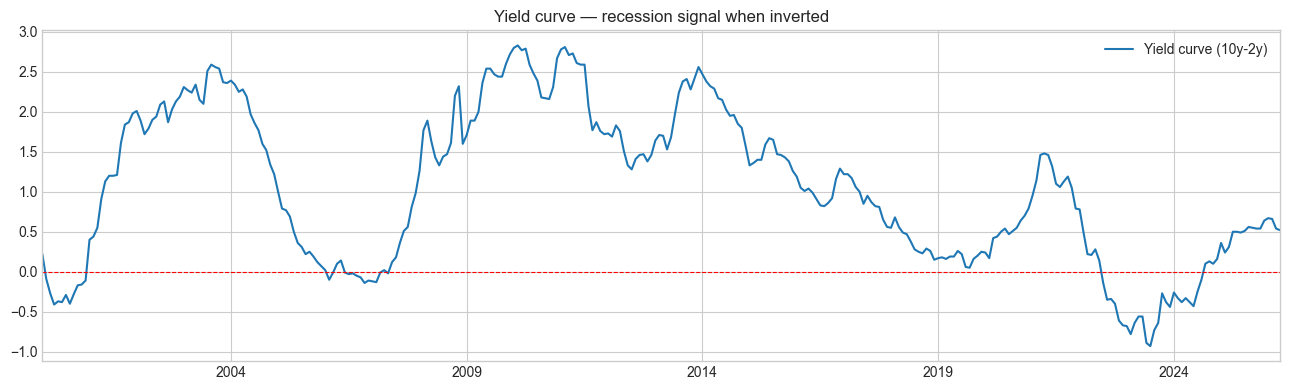

,yield_curve,vix,hy_spread
2025-12-31,0.64,14.950000,2.81
2026-01-31,0.67,17.440001,2.88
2026-02-28,0.66,19.860001,3.12
2026-03-31,0.54,25.250000,3.28
2026-04-30,0.52,16.889999,2.83


In [6]:
fig, ax = plt.subplots(figsize=(13, 4))
macro['yield_curve'].plot(ax=ax, label='Yield curve (10y-2y)')
ax.axhline(0, color='red', ls='--', lw=0.8)
ax.set_title('Yield curve — recession signal when inverted'); ax.legend()
plt.tight_layout(); plt.show()

macro.tail()

## Notes

- Run with a small universe via `python -m pipelines.build_dataset --quick 30`; full run drops `--quick`.
- Fundamentals are **point-in-time** (EDGAR filing dates) — the panel stage (notebook 02) forward-fills each quarter from its `availability_date`.
- **Next**: `notebooks/02_panel_eda.ipynb` — assemble the `(ticker, month)` feature panel.